# Algoritmos Supervisionados (MLP e KNN)

Este relatório descreve como aplicamos junto a uma rede neural MLP, a técnica de classificação KNN na base de dados Shuttle (Statlog). Também contém escolhas e justificativas dos parâmetros e técnicas utilizadas, assim como uma indicação objetiva de qual algoritmo é melhor para a base selecionada.

## Base de Dados Shuttle

A base de dados Shuttle contém informações sobre uma grande quantidade de dados relacionados ao transporte de astronautas no ônibus espacial Shuttle, e tarefa de classificação desse dataset envolve prever qual o tipo de falha ocorreu durante o processo.

### Características da Base de Dados

- **Número de amostras**: 58000 instâncias (linhas de dados).
- **Atributos**: 8 características, incluindo a variável alvo.
    - Flight Number (Número do vôo)
    - Altitude (Altitude do vôo)
    - Temperature (Temperatura no vôo)
    - Pressure (Pressão)
    - Wind (Vento)
    - Turbulence (Turbulência)
    - Fuel Type (Tipo de combustível)
- **Objetivo**: A tarefa principal é classificar o estado operacional do ônibus espacial, que é uma variável categórica com 7 classes possíveis, como operação normal, falha no sistema de propulsão, falha no sistema hidráulico, falha no sistema elétrico, entre outras.

### Comportamento em Algoritmos Supervisionados

O dataset Shuttle do Statlog é usado para classificação multiclasse com sete categorias, mas apresenta um desequilíbrio nas classes, onde algumas são muito mais frequentes que outras (1). Isso pode levar os algoritmos a favorecerem as classes majoritárias, dificultando a identificação das minoritárias. Como o conjunto é composto por variáveis numéricas de sensores, métodos como redes neurais, SVM e algoritmos baseados em árvores costumam ter bom desempenho.

## Análise Exploratória de Dados Shuttle

Neste relatório será realizada uma análise exploratória do dataset Shuttle do Statlog, com o objetivo de compreender melhor suas características antes da aplicação de algoritmos supervisionados. Serão apresentados dados gerais, como o número de amostras e atributos, além da verificação da presença de valores ausentes. Também será feita uma análise da distribuição da variável alvo, que representa os diferentes estados operacionais do ônibus espacial, bem como a distribuição das variáveis numéricas provenientes dos sensores. Ademais, exploraremos a correlação entre os atributos e a composição das variáveis categóricas, quando presentes. Esta análise inicial é essencial para identificar padrões, desequilíbrios nas classes e outras particularidades dos dados que podem impactar a escolha, o ajuste e o desempenho dos modelos de aprendizado supervisionado.

1. Carregamento e Primeira Visão dos Dados


In [87]:
# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_shuttle = fetch_ucirepo(id=148) 
  
# data (as pandas dataframes) 
X = statlog_shuttle.data.features 
y = statlog_shuttle.data.targets 

# Estatísticas descritivas das features
print(X.describe())


           Rad Flow     Fpv Close      Fpv Open          High        Bypass  \
count  58000.000000  58000.000000  58000.000000  58000.000000  58000.000000   
mean      85.349121      0.259672     34.549862      1.608190     37.092310   
std        8.902769     36.521516     21.660139    217.597675     13.111428   
min       21.000000  -3939.000000   -188.000000 -26739.000000    -48.000000   
25%       79.000000      0.000000     26.000000     -5.000000     32.000000   
50%       83.000000      0.000000     42.000000      0.000000     39.000000   
75%       89.000000      0.000000     46.000000      5.000000     42.000000   
max      149.000000   3830.000000    436.000000  15164.000000    105.000000   

          Bpv Close      Bpv Open  
count  58000.000000  58000.000000  
mean      50.884552     13.932414  
std       21.418051     25.614018  
min     -353.000000   -356.000000  
25%       37.000000      0.000000  
50%       44.000000      2.000000  
75%       60.000000     14.000000  


O dataset utilizado possui 58.000 amostras e diversas variáveis contínuas, representando medições de sensores industriais. A análise estatística inicial revela que algumas variáveis, como Rad Flow e Bypass, apresentam distribuição relativamente estável, com valores bem concentrados em torno da média e sem grandes variações.

Por outro lado, atributos como Fpv Close, High, Bpv Close e Bpv Open demonstram forte presença de valores extremos e negativos, o que levanta suspeitas de possíveis anomalias ou falhas de medição. Por exemplo, a variável High tem valores que variam de -26.739 a +15.164, com média próxima de 1,60 e mediana igual a zero — um forte indicativo de dados assimétricos com outliers severos.

A presença dessas discrepâncias pode impactar negativamente o desempenho de algoritmos supervisionados, especialmente aqueles sensíveis à escala dos dados, como o KNN e o MLP. Por isso, será necessário aplicar técnicas de pré-processamento, como a normalização.

2. Análise da Variável Alvo

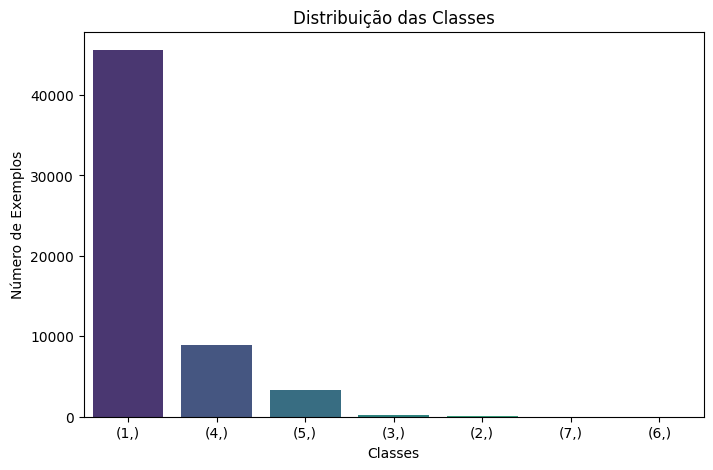

class
1        45586
4         8903
5         3267
3          171
2           50
7           13
6           10
Name: count, dtype: int64


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar a contagem das classes
class_counts = y.value_counts()

# Converter índice para lista simples de strings (para evitar erros)
labels = class_counts.index.tolist()
labels = [str(label) for label in labels]

# Plotar o gráfico
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, hue=labels, y=class_counts.values, palette="viridis")

plt.title("Distribuição das Classes")
plt.xlabel("Classes")
plt.ylabel("Número de Exemplos")
plt.show()

print(class_counts)

Esse gráfico nos mostra que a variável alvo é discreta, e não contínua. Ou seja, algoritmos de classificação são os mais indicados para agrupar essa base de dados. Por conta disso, vamos utilizar classificação para o KNN, e não regressão.

Além disso, a variável alvo no dataset é composta por sete classes distintas, porém com uma distribuição altamente desbalanceada. A classe 1 domina amplamente os dados, com 45.586 amostras, representando cerca de 79% do total. Em seguida, a classe 4 aparece com 8.903 registros (cerca de 15%), enquanto as demais classes possuem representações bastante reduzidas: a classe 5 tem 3.267 amostras, a classe 3 apenas 171, e as classes 2, 6 e 7 somam juntas apenas 73 amostras (menos de 0,2%).

Esse desequilíbrio pode causar sérios problemas durante o treinamento dos modelos de classificação. Algoritmos supervisionados tendem a favorecer as classes majoritárias, resultando em altas acurácias globais mas baixa performance para as classes minoritárias, especialmente em termos de precisão, recall e F1-score.

Diante disso, será importante considerar abordagens específicas para tratar o desbalanceamento, como:

- Ajuste de pesos nas classes.

- Avaliação por métricas mais robustas, como a média ponderada do F1-score, em vez de apenas acurácia.

3. Análise das Variáveis Numéricas

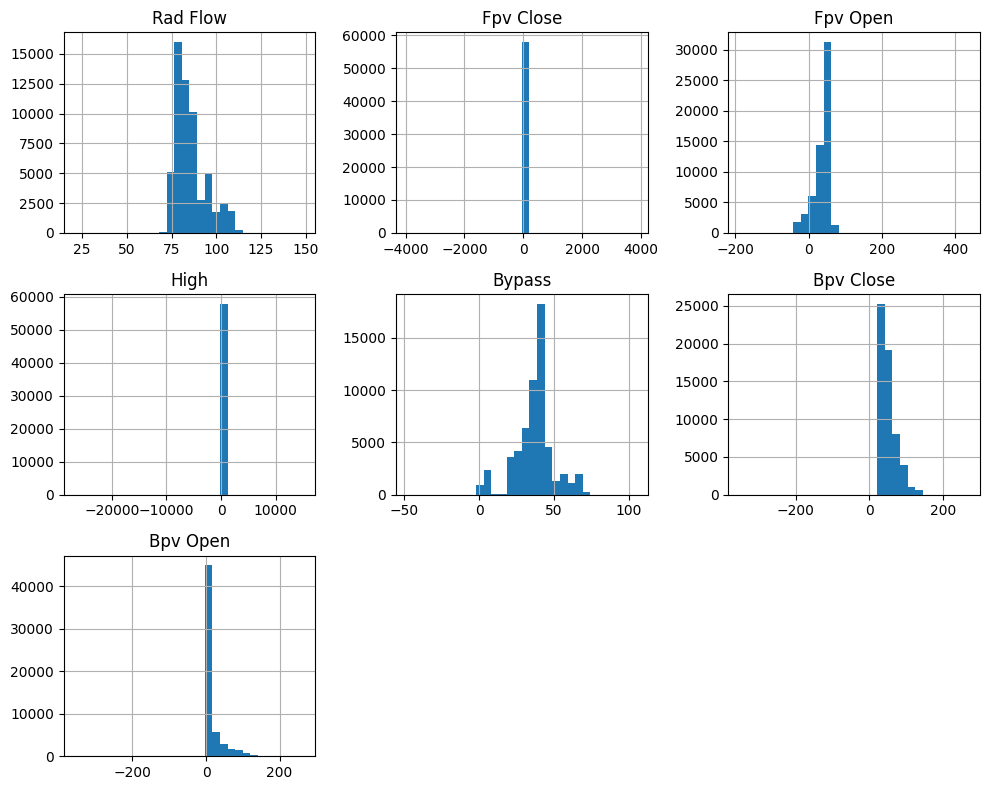

In [89]:
# Histograma de todas as variáveis

X.hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

A visualização das distribuições das variáveis revela comportamentos distintos entre os atributos. Variáveis como Rad Flow, Bypass, Bpv Close e Bpv Open apresentam distribuições relativamente regulares, com boa dispersão e formas próximas do esperado para sensores físicos. Essas variáveis devem contribuir positivamente para o desempenho dos modelos.

Por outro lado, os atributos Fpv Close e High concentram quase todos os valores em torno de zero, mas apresentam outliers extremamente distantes do centro. Isso indica um comportamento anômalo, sugerindo que essas variáveis podem precisar de tratamento específico, como normalização. O atributo Fpv Open também mostra certa assimetria e pode se beneficiar de escalonamento.

De forma geral, os histogramas reforçam a necessidade de padronizar os dados antes de aplicar os algoritmos supervisionados.

4. Matriz de Correlação

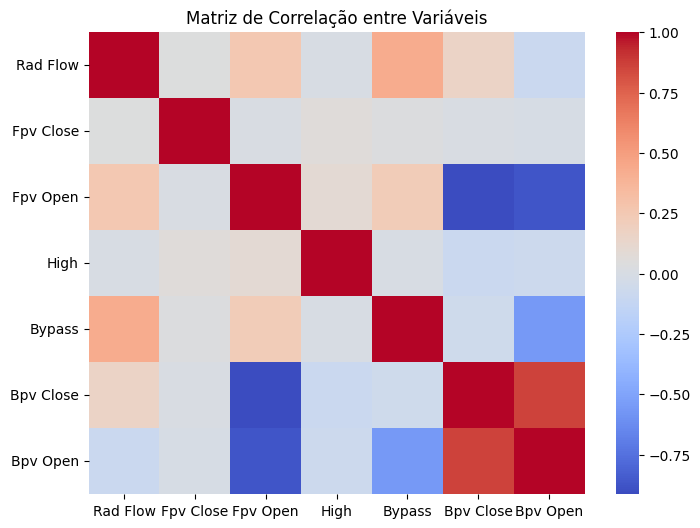

In [90]:
# Matriz de correlação
corr = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

A matriz de correlação mostra que, de modo geral, as variáveis do dataset Shuttle não são fortemente correlacionadas entre si, o que é desejável para modelos supervisionados — pois indica que cada atributo pode conter informações complementares.

Os únicos pares com correlações fortes (positiva ou negativa) são:

- Bpv Close e Bpv Open: apresentam forte correlação positiva, próxima de +1, indicando que são altamente redundantes. Pode ser interessante manter apenas uma das duas para evitar colinearidade nos modelos.

- Fpv Open e Bpv Close / Bpv Open: há correlação negativa forte, especialmente com Bpv Close (quase -1), o que também indica redundância entre essas variáveis.

- Bypass e Rad Flow têm correlação moderada positiva, o que pode refletir alguma relação funcional entre os sensores.

Demais variáveis mostram correlações fracas ou inexistentes, o que é positivo, pois reduz o risco de multicolinearidade e favorece o aprendizado de padrões distintos por parte dos algoritmos.

Com isso, decidimos aplicar PCA para reduzir a colinearidade ao máximo e para aumentar o desempenho dos algoritmos.

## Algoritmo KNN

Primeiramente, precisamos decidir se vamos utilizar classificação ou regressão com o algoritmo KNN. Utilizamos classificação quando o rótulo for categórico ou discreto. Ou seja, quando desejamos prever uma categoria ou classe (por exemplo, 'sim' ou 'não', 'gato' ou 'cachorro'). O KNN irá prever a classe da nova amostra com base no voto da maioria dos seus k vizinhos mais próximos. Por outro lado, utilizamos regressão quando o rótulo for contínuo, ou seja, um número real (por exemplo: altura, preço, temperatura). Nesse caso, o KNN retorna a média (ou média ponderada) dos valores dos vizinhos mais próximos.

Dessa forma, decidimos utilizar o KNN para classificação por três motivos principais:

1. A variável-alvo do conjunto de dados Shuttle representa sete modos operacionais distintos da nave espacial, numerados de 1 a 7. Segundo a descrição da base no UCI Machine Learning Repository, esses valores inteiros indicam diferentes classes de modos de operação do sistema.

2. Os gráficos da análise preliminar mostram que a variável-alvo é discreta, com uma distribuição claramente categórica entre essas sete classes. Isso confirma que se trata de uma tarefa de classificação multiclasse.

3. O respositório analisado utiliza o algoritmo MLPClassifier, que é também um classificador. Comparar dois classificadores (MLPClassifier vs. KNN) mantém a coerência metodológica e permite avaliar desempenho em uma mesma tarefa supervisionada.

#### Gráfico de Apoio

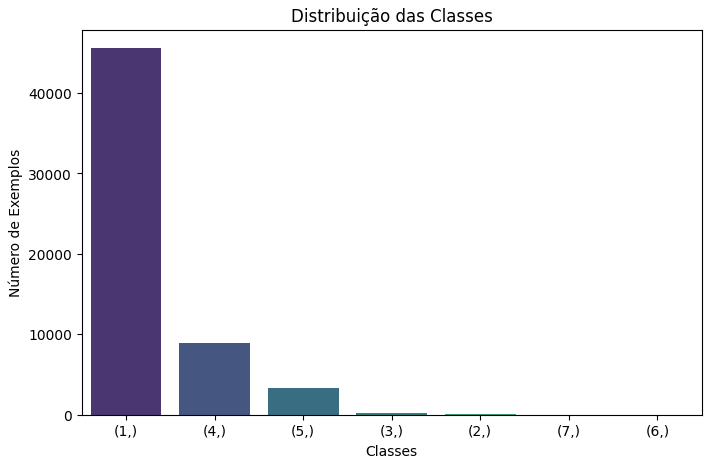

O gráfico acima mostra claramente que a variável-alvo não possui continuidade, sendo mais adequado o uso de algoritmos de classificação.

Dessa forma, podemos iniciar a importação das bibliotecas necessárias, carregar o dataset e preparar os dados.

Nesta primeira etapa, o código está carregando o conjunto de dados "Statlog (Shuttle)" a partir da biblioteca ucimlrepo, que facilita o acesso a conjuntos de dados do repositório da UCI Machine Learning.

- fetch_ucirepo(id=148) baixa o dataset Shuttle, identificado pelo ID 148 no repositório.

- X recebe as features (atributos preditores) como um DataFrame.

- y recebe a variável alvo (ou classe a ser prevista).

In [96]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

statlog_shuttle = fetch_ucirepo(id=148) 
  
X = statlog_shuttle.data.features 
y = statlog_shuttle.data.targets

Em seguida, os dados são divididos em treino (80%) e teste (20%) com train_test_split. A escolha de test_size=0.2 garante uma amostra suficiente para avaliação sem prejudicar o aprendizado. O parâmetro stratify=y preserva a proporção das classes em ambas as partes, essencial em datasets desbalanceados como o Shuttle. Já random_state=42 assegura reprodutibilidade, permitindo que os mesmos dados sejam separados em todas as execuções.

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

Depois, os dados são padronizados com StandardScaler, que transforma as features para que tenham média zero e desvio padrão um. Esse escalonamento é fundamental para algoritmos que se baseiam em distâncias, como o KNN, garantindo que todas as variáveis contribuam igualmente. O scaler é ajustado (fit) apenas nos dados de treino para evitar vazamento de informação, e em seguida aplicado (transform) tanto no treino quanto no teste.

In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Neste trecho, aplica-se PCA para reduzir a dimensionalidade dos dados mantendo 95% da variância explicada. Primeiro, ajusta-se o PCA aos dados de treino para analisar a variância acumulada e definir o número ideal de componentes. Com n_components=0.95, o PCA seleciona automaticamente 5 componentes principais, o que preserva a maior parte da informação dos dados. 
A transformação é feita após o ajuste no treino, garantindo que não haja vazamento de informação para o teste.

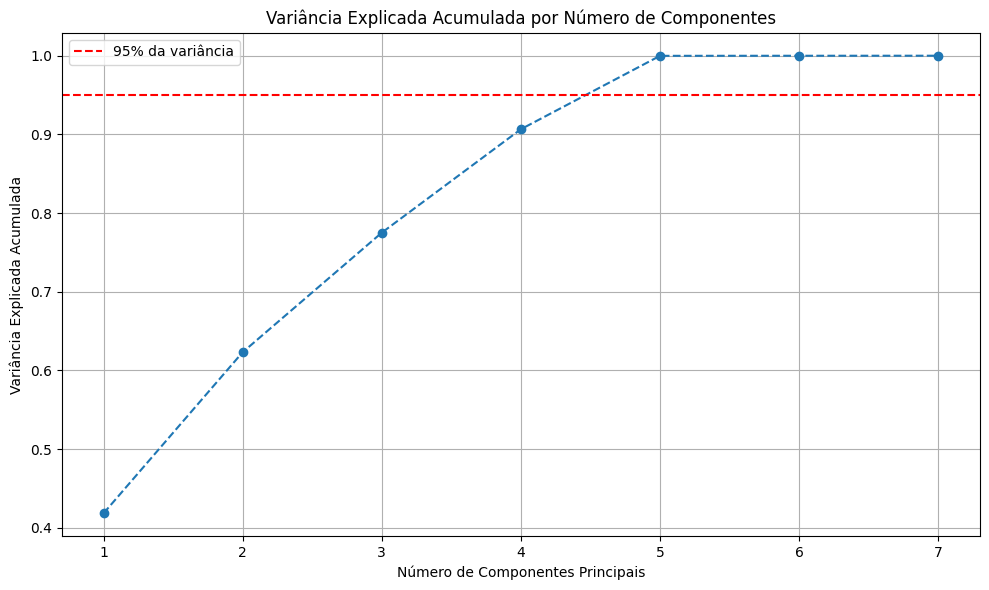

Número de componentes principais mantidos: 5


In [99]:
# Ajustar PCA no treino (com análise da variância explicada)
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot da variância explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Número de Componentes')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% da variância')
plt.legend()
plt.tight_layout()
plt.show()

# Aplicar PCA com 95% da variância
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Número de componentes principais mantidos: {pca.n_components_}")

Continuando, realiza-se a busca pelos melhores hiperparâmetros para o classificador KNN usando GridSearchCV. O grid explora combinações entre:

- k (número de vizinhos) de 1 a 20,

- duas métricas de distância: euclidiana e manhattan,

- e dois esquemas de ponderação: uniforme (todos os vizinhos têm o mesmo peso) e distance (vizinhos mais próximos têm maior peso).

A validação cruzada com cv=5 é usada para estimar o desempenho médio de cada combinação de forma mais robusta. O parâmetro scoring='accuracy' indica que a métrica usada para selecionar o melhor modelo é a acurácia. O ajuste é feito sobre os dados reduzidos pelo PCA. O resultado inclui a melhor combinação de parâmetros e a acurácia média obtida na validação cruzada.

In [100]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train_pca, y_train.values.ravel())

print("Melhores parâmetros encontrados:", grid_search.best_params_)
print("Melhor acurácia média na validação cruzada:", grid_search.best_score_)

results = pd.DataFrame(grid_search.cv_results_)

Melhores parâmetros encontrados: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'}
Melhor acurácia média na validação cruzada: 0.9977801724137931


Neste trecho, os resultados do GridSearchCV são visualizados em um gráfico que mostra a acurácia média de validação cruzada para cada valor de k (de 1 a 20), considerando todas as combinações de métrica de distância (euclidean e manhattan) e tipo de peso (uniform e distance).

Cada linha do gráfico representa uma dessas combinações, permitindo comparar visualmente o impacto de cada parâmetro no desempenho do KNN. Essa visualização facilita a escolha dos hiperparâmetros ao mostrar não apenas o melhor valor, mas também a estabilidade do modelo em diferentes configurações.

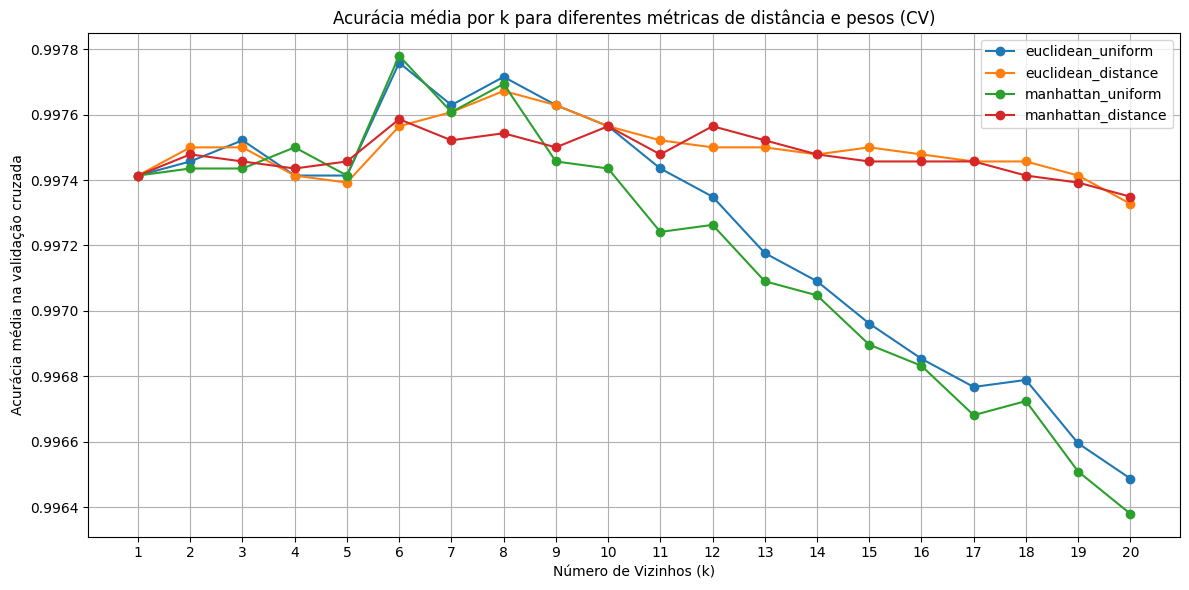

In [101]:
k_values = list(range(1, 21))
distances = ['euclidean', 'manhattan']
weights = ['uniform', 'distance']

plt.figure(figsize=(12, 6))

for dist in distances:
    for weight in weights:
        subset = results[
            (results['param_metric'] == dist) & 
            (results['param_weights'] == weight)
        ]
        subset = subset.sort_values('param_n_neighbors')
        plt.plot(k_values, subset['mean_test_score'], marker='o', label=f'{dist}_{weight}')

plt.title('Acurácia média por k para diferentes métricas de distância e pesos (CV)')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia média na validação cruzada')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

Neste trecho, o código identifica, para cada combinação de métrica de distância (euclidean e manhattan) e tipo de peso (uniform e distance), o valor de k (número de vizinhos) que resultou na maior acurácia média durante a validação cruzada.

Ele filtra os resultados do GridSearchCV para cada par de parâmetros, encontra o índice do melhor desempenho (idxmax), e imprime o valor de k correspondente junto com a acurácia associada.

Essa análise é útil para destacar, dentre as várias configurações testadas, quais combinações específicas de parâmetros levaram ao melhor desempenho do modelo, facilitando a escolha do modelo final.

In [102]:
for dist in distances:
    for weight in weights:
        subset = results[
            (results['param_metric'] == dist) &
            (results['param_weights'] == weight)
        ]
        best_idx = subset['mean_test_score'].idxmax()
        best_k = subset.loc[best_idx, 'param_n_neighbors']
        best_acc = subset.loc[best_idx, 'mean_test_score']
        print(f'Melhor k para {dist}_{weight}: {best_k} com acurácia {best_acc:.4f}')

Melhor k para euclidean_uniform: 6 com acurácia 0.9978
Melhor k para euclidean_distance: 8 com acurácia 0.9977
Melhor k para manhattan_uniform: 6 com acurácia 0.9978
Melhor k para manhattan_distance: 6 com acurácia 0.9976


Neste trecho, o modelo KNN final é treinado com os melhores parâmetros encontrados pelo GridSearchCV usando o conjunto de treino transformado pelo PCA. Em seguida, o modelo é avaliado no conjunto de teste, também transformado pelo PCA.

São calculadas três métricas principais para medir o desempenho:

- Acurácia: proporção de previsões corretas.

- Precisão ponderada: média da precisão para cada classe, levando em conta o desequilíbrio das classes.

- Recall ponderado: média do recall por classe, também ponderada pela frequência das classes.

Essas métricas fornecem uma avaliação mais completa do desempenho, especialmente em datasets desbalanceados como o Shuttle. O parâmetro zero_division=0 evita erros caso alguma classe não seja prevista. Essa etapa confirma o desempenho real do modelo em dados nunca vistos.

In [103]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

knn_final = grid_search.best_estimator_
knn_final.fit(X_train_pca, y_train.values.ravel())

y_pred_knn = knn_final.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print("\nAvaliação final no conjunto de teste:")
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Avaliação final no conjunto de teste:
Acurácia: 0.9979
Precisão: 0.9974
Recall: 0.9979


No último trecho, é gerada a matriz de confusão para visualizar o desempenho detalhado do modelo KNN no conjunto de teste. A matriz mostra, para cada classe real (eixo y), quantas amostras foram corretamente classificadas ou confundidas com outras classes (eixo x).

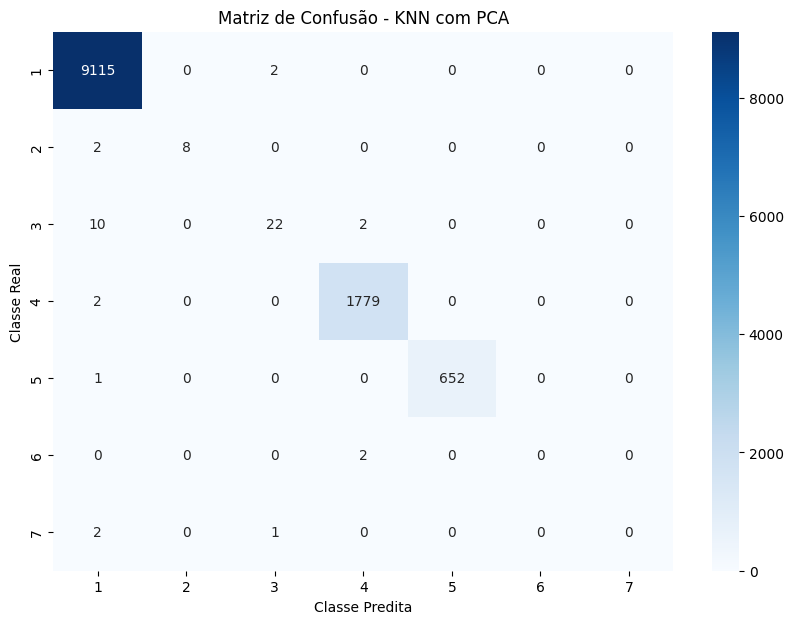

In [104]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão - KNN com PCA")
plt.show()

Como podemos perceber, o algoritmo fez pouquíssimas previsões incorretas, o que justifica seus valores de acurácia, precisão e recall estarem tão próximos de 1.

In [105]:
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred_knn, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(3)

print("Relatório de Classificação:")
display(df_report)

Relatório de Classificação:


,precision,recall,f1-score,support
1,0.998,1.000,0.999,9117.000
2,1.000,0.800,0.889,10.000
3,0.880,0.647,0.746,34.000
4,0.998,0.999,0.998,1781.000
5,1.000,0.998,0.999,653.000
6,0.000,0.000,0.000,2.000
7,0.000,0.000,0.000,3.000
accuracy,0.998,0.998,0.998,0.998
macro avg,0.697,0.635,0.662,11600.000
weighted avg,0.997,0.998,0.998,11600.000


A respeito das métricas acima e o que elas representam:

- precision (Precisão): mede a proporção de previsões positivas corretas sobre todas as previsões positivas feitas para cada classe. Ou seja, do total que o modelo classificou como uma classe, quantos estavam realmente corretos.

- recall (Revocação ou Sensibilidade): mede a proporção de verdadeiros positivos capturados sobre o total real daquela classe. Ou seja, do total real daquela classe, quantos foram identificados corretamente pelo modelo.

- f1-score: é a média harmônica entre precisão e recall, equilibrando os dois. Indica o desempenho geral da classe considerando tanto falsos positivos quanto falsos negativos.

- support: número de amostras reais presentes naquela classe no conjunto de teste.

- accuracy: proporção total de previsões corretas considerando todas as classes.

- macro avg: média simples dos valores de precision, recall e f1-score, tratando todas as classes igualmente.

- weighted avg: média ponderada dessas métricas, levando em conta o suporte (quantidade) de cada classe.

## Algoritmo MLP

Vamos iniciar importando das bibliotecas necessárias, carregando o dataset e preparando os dados.

Nesta primeira etapa, o código está carregando o conjunto de dados "Statlog (Shuttle)" a partir da biblioteca ucimlrepo, que facilita o acesso a conjuntos de dados do repositório da UCI Machine Learning.

- fetch_ucirepo(id=148) baixa o dataset Shuttle, identificado pelo ID 148 no repositório.

- X recebe as features (atributos preditores) como um DataFrame.

- y recebe a variável alvo (ou classe a ser prevista).

In [119]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

statlog_shuttle = fetch_ucirepo(id=148)

X = statlog_shuttle.data.features
y = statlog_shuttle.data.targets

O código abaixo divide os dados originais em treino e teste, separando 70% para treino e 30% para teste. A divisão é feita de forma que a proporção das classes se mantenha igual nos dois conjuntos, garantindo um equilíbrio. Também é definida uma semente fixa para que essa divisão seja sempre a mesma em diferentes execuções, facilitando a reprodução dos resultados.

In [120]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Aqui o código normaliza os dados usando o StandardScaler, que transforma as variáveis para terem média zero e desvio padrão um. Primeiro, o scaler aprende os parâmetros (média e desvio) do conjunto de treino e aplica a transformação nele. Depois, esses mesmos parâmetros são usados para normalizar o conjunto de teste, garantindo que ambos estejam na mesma escala. Essa padronização ajuda o modelo a convergir melhor e evita que variáveis com diferentes escalas influenciem desproporcionalmente o aprendizado.

In [121]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

O trecho do código a seguir aplica PCA para reduzir a dimensionalidade dos dados normalizados. Primeiro, calculamos e plotamos a variância acumulada explicada por cada componente, mostrando visualmente quantos componentes são necessários para manter uma boa parte da informação. O gráfico indica que 5 componentes principais são suficientes para preservar 95% da variância dos dados. Em seguida, o PCA é configurado para manter esses 5 componentes, que serão usados para transformar tanto o conjunto de treino quanto o de teste. Essa redução ajuda a simplificar o modelo e pode melhorar a eficiência sem perder muita informação relevante.

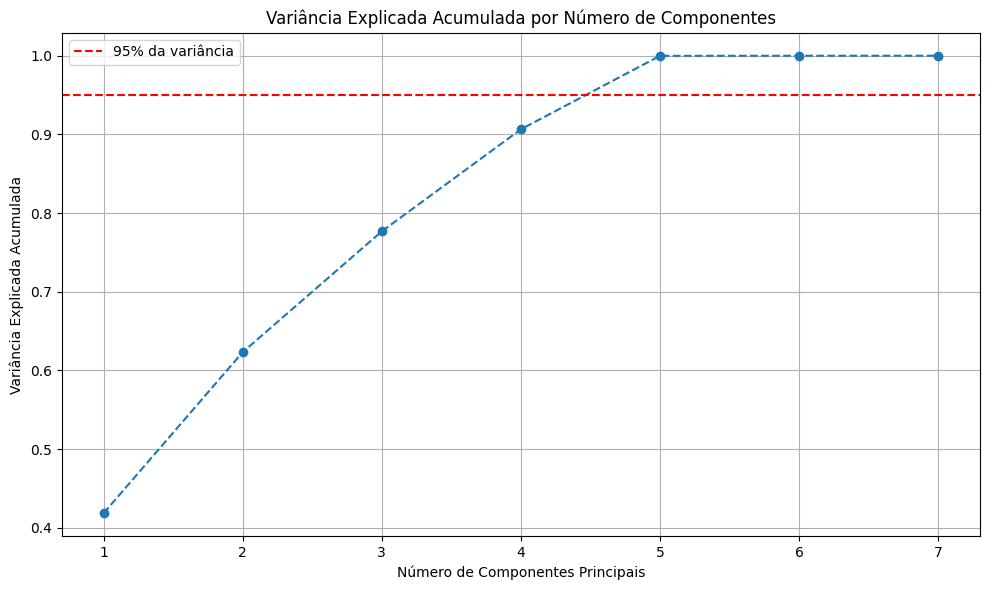

Número de componentes principais mantidos: 5


In [122]:
pca_full = PCA()
pca_full.fit(X_train_norm)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Número de Componentes')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% da variância')
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_norm)
X_test_pca = pca.transform(X_test_norm)

print(f"Número de componentes principais mantidos: {pca.n_components_}")

O trecho abaixo usa GridSearchCV para testar várias combinações de hiperparâmetros do MLPClassifier, buscando o melhor desempenho na base Shuttle. São avaliados diferentes tamanhos e números de camadas ocultas, funções de ativação, taxas de aprendizado, número de iterações e otimizadores (Adam e SGD). Para o SGD, também se testam tamanhos de batch variados. A validação cruzada com 3 folds garante uma avaliação mais confiável.

As escolhas dos parâmetros cobrem aspectos importantes do treinamento:

- O tamanho e número das camadas ocultas controlam a complexidade do modelo.

- As funções de ativação permitem capturar diferentes padrões não lineares.

- As taxas de aprendizado buscam equilíbrio entre velocidade e estabilidade.

- O limite de iterações evita treinos muito longos.

- Diferentes otimizadores e tamanhos de batch testam alternativas para uma melhor convergência e generalização.

Essa abordagem amplia as chances de encontrar uma configuração eficiente e bem ajustada para o problema.

In [123]:
param_grid = [
    {
        'hidden_layer_sizes': [
            (50,), (100,),        
            (50, 50), (100, 50)   
        ],
        'activation': ['logistic', 'relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01],
        'max_iter': [200, 300],
        'solver': ['adam']  
    },
    {
        'hidden_layer_sizes': [
            (50,), (100,),        
            (50, 50), (100, 50)   
        ],
        'activation': ['logistic', 'relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01],
        'max_iter': [200, 300],
        'solver': ['sgd'],
        'batch_size': [64, 128]
    }
]

mlp = MLPClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train.values.ravel())

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

print(f"\nMelhor acurácia média na validação cruzada: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Melhores parâmetros encontrados:
{'activation': 'tanh', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001, 'max_iter': 200, 'solver': 'adam'}

Melhor acurácia média na validação cruzada: 0.9981


Aqui o código usa o melhor modelo encontrado na busca em grade para fazer previsões no conjunto de teste reduzido pelo PCA. Em seguida, calcula a acurácia dessas previsões comparando com as classes reais, fornecendo uma medida objetiva do desempenho do modelo em dados nunca vistos. Isso permite avaliar se o modelo generaliza bem para novos exemplos, confirmando a eficácia dos parâmetros selecionados.

In [124]:
y_pred = grid_search.best_estimator_.predict(X_test_pca)
acc_test = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acc_test:.4f}")

Acurácia no conjunto de teste: 0.9982


Esse trecho organiza os resultados da busca em grade em um DataFrame, ordenando as combinações de parâmetros pela melhor acurácia média na validação cruzada. Depois, imprime as 10 melhores configurações, permitindo analisar quais ajustes geraram os melhores resultados. Isso ajuda a entender o impacto dos parâmetros no desempenho e facilita decisões para futuras otimizações.

In [125]:
df_results = pd.DataFrame(grid_search.cv_results_)
df_results = df_results.sort_values(by='mean_test_score', ascending=False)
print("\nTop 10 combinações:")
print(df_results[['params', 'mean_test_score']].head(10))


Top 10 combinações:
                                               params  mean_test_score
41  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.998079
40  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.998079
3   {'activation': 'logistic', 'hidden_layer_sizes...         0.998054
2   {'activation': 'logistic', 'hidden_layer_sizes...         0.998054
6   {'activation': 'logistic', 'hidden_layer_sizes...         0.998054
7   {'activation': 'logistic', 'hidden_layer_sizes...         0.998054
44  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.998054
45  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.998054
18  {'activation': 'relu', 'hidden_layer_sizes': (...         0.997980
19  {'activation': 'relu', 'hidden_layer_sizes': (...         0.997980


Esse código extrai dos parâmetros testados pelo GridSearchCV colunas separadas para cada hiperparâmetro, como tamanho das camadas ocultas, função de ativação, otimizador, taxa de aprendizado, número máximo de iterações e batch size. Também renomeia a coluna de média da acurácia para “accuracy” para facilitar a leitura. Por fim, cria uma nova coluna com a representação em texto dos tamanhos das camadas ocultas, o que ajuda a visualizar e comparar melhor os resultados em tabelas ou gráficos. Essa organização deixa os dados mais claros para análise e interpretação dos efeitos de cada parâmetro no desempenho.

In [126]:
df_results['hidden_layer_sizes'] = df_results['params'].apply(lambda x: x.get('hidden_layer_sizes'))
df_results['activation'] = df_results['params'].apply(lambda x: x.get('activation'))
df_results['solver'] = df_results['params'].apply(lambda x: x.get('solver'))
df_results['learning_rate_init'] = df_results['params'].apply(lambda x: x.get('learning_rate_init'))
df_results['max_iter'] = df_results['params'].apply(lambda x: x.get('max_iter'))
df_results['batch_size'] = df_results['params'].apply(lambda x: x.get('batch_size', None))
df_results['learning_rate'] = df_results['params'].apply(lambda x: x.get('learning_rate', None))

df_results.rename(columns={'mean_test_score': 'accuracy'}, inplace=True)

df_results['hidden_str'] = df_results['hidden_layer_sizes'].astype(str)

Esse gráfico de caixa (boxplot) mostra como a acurácia varia para diferentes funções de ativação, separando os resultados pelos otimizadores usados (solvers). Assim, é possível visualizar qual combinação de função de ativação e solver tende a gerar melhor desempenho e qual apresenta maior consistência nos resultados. Essa análise ajuda a entender o impacto desses parâmetros no desempenho do MLP na base Shuttle.

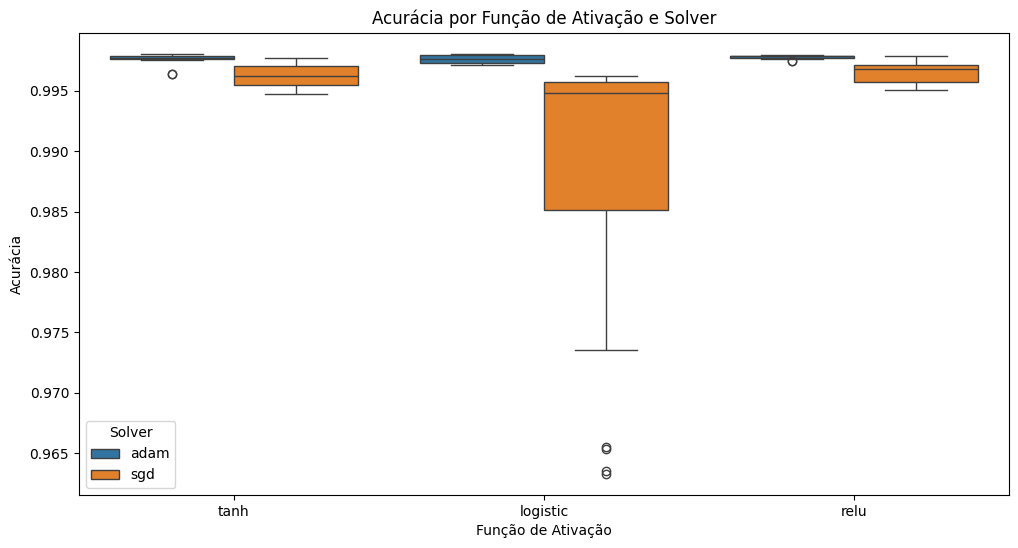

In [127]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_results, x='activation', y='accuracy', hue='solver')
plt.title('Acurácia por Função de Ativação e Solver')
plt.xlabel('Função de Ativação')
plt.ylabel('Acurácia')
plt.legend(title='Solver')
plt.show()

O gráfico acima sugere que, para este modelo e base de dados:

- adam é o solver mais confiável.

- As funções de ativação tanh e relu funcionam melhor com adam.

- Devemos evitar a combinação logistic + sgd por seu desempenho instável.

Em seguida, esse gráfico de barras mostra a acurácia média obtida para cada configuração de camadas ocultas, com as barras de erro representando o desvio padrão. Ele ajuda a comparar o desempenho médio de diferentes arquiteturas do MLP, evidenciando quais estruturas tendem a ser mais eficazes e estáveis na base Shuttle. Assim, fica mais fácil escolher a arquitetura ideal para o problema.

- Eixo X (Camadas Ocultas): Representa diferentes arquiteturas de rede neural, como:

- (50, 50): duas camadas ocultas com 50 neurônios cada

- (50,): uma camada oculta com 50 neurônios

- (100,): uma camada oculta com 100 neurônios

- (100, 50): duas camadas ocultas, a primeira com 100 e a segunda com 50 neurônios

- Eixo Y (Acurácia Média): Média da acurácia obtida nos testes para cada arquitetura.

- Barras de erro: Representam o desvio padrão da acurácia (variabilidade dos resultados).

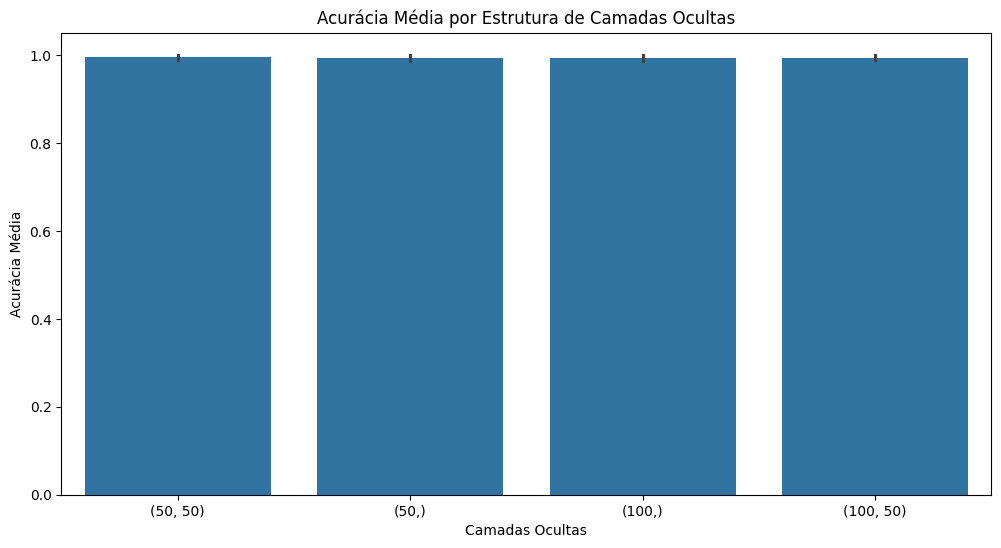

In [128]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='hidden_str', y='accuracy', estimator='mean', errorbar='sd')
plt.title('Acurácia Média por Estrutura de Camadas Ocultas')
plt.xlabel('Camadas Ocultas')
plt.ylabel('Acurácia Média') 
plt.show()

Análise:
1. Todas as arquiteturas obtêm acurácia muito alta (~1.0):

    - Isso indica que os dados são provavelmente bem separáveis ou o modelo está bem ajustado.

2. Pequenas diferenças entre as arquiteturas:

    - A variação entre (50,), (50, 50), (100,) e (100, 50) é muito pequena, o que indica que a complexidade da rede (mais neurônios ou camadas) não tem impacto significativo na acurácia nesse caso.

3. Barras de erro muito pequenas:

    - O desvio padrão é baixo, o que sugere que os resultados são consistentes entre diferentes execuções ou folds de validação.

Logo após, o boxplot abaixo exibe como a acurácia varia conforme o tamanho do batch quando o otimizador utilizado é o SGD. A visualização permite entender se diferentes tamanhos de lote influenciam a performance do modelo, mostrando a distribuição e a consistência dos resultados para cada opção de batch size. Isso ajuda a escolher o batch size mais adequado para otimizar o desempenho do MLP com SGD na base Shuttle.

- Eixo X (Batch Size): Tamanhos de lote testados: 64 e 128.

- Eixo Y (Acurácia): Distribuição da acurácia dos modelos treinados com esses valores.

- Boxplots: Mostram a mediana (linha dentro da caixa), os quartis (limites da caixa), e os outliers (círculos).

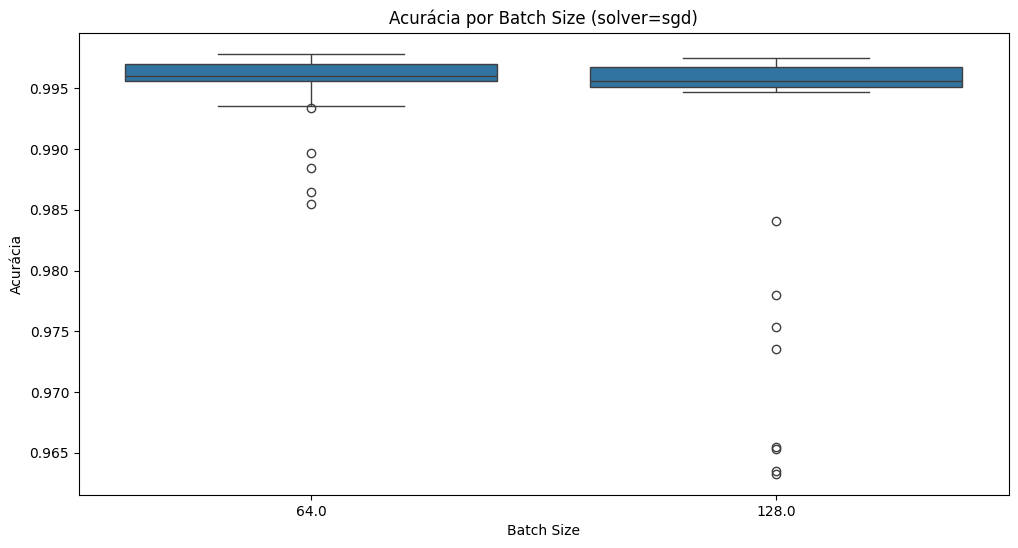

In [129]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_results[df_results['solver'] == 'sgd'],
    x='batch_size',
    y='accuracy'
)
plt.title('Acurácia por Batch Size (solver=sgd)')
plt.xlabel('Batch Size')
plt.ylabel('Acurácia')
plt.show()

Análise:
1. Acurácia mais estável com batch size = 64:
    - O boxplot de 64 é mais compacto (menor dispersão).

    - Menos outliers — isso indica que os resultados foram mais consistentes.

2. Maior variabilidade com batch size = 128:
    - Embora a mediana ainda esteja alta, há mais outliers negativos (valores baixos de acurácia).

    - Isso mostra que o desempenho foi mais instável, com casos onde a rede teve dificuldades de convergência ou generalização.

Em seguida, a matriz de confusão mostra, de forma visual, quantas previsões do modelo foram corretas ou incorretas para cada classe no conjunto de teste. As células diagonais representam as classificações certas, enquanto as fora da diagonal indicam os erros. Esse gráfico ajuda a identificar quais classes o modelo reconhece bem e onde ele tem mais dificuldades, oferecendo insights importantes para melhorias futuras no classificador.

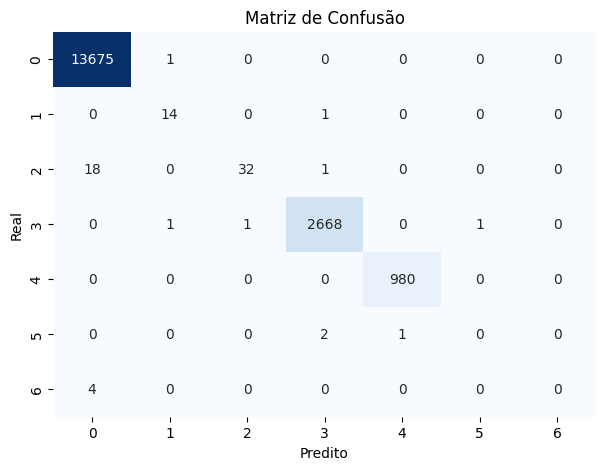

In [130]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

Como podemos perceber, o algoritmo fez pouquíssimas previsões incorretas, o que justifica seus valores de acurácia, precisão, recall e f1-score estarem tão próximos de 1, como mostra a tabela de classificação abaixo.

In [131]:
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(3)

print("Relatório de Classificação:")
display(df_report)

Relatório de Classificação:


,precision,recall,f1-score,support
1,0.998,1.000,0.999,13676.000
2,0.875,0.933,0.903,15.000
3,0.970,0.627,0.762,51.000
4,0.999,0.999,0.999,2671.000
5,0.999,1.000,0.999,980.000
6,0.000,0.000,0.000,3.000
7,0.000,0.000,0.000,4.000
accuracy,0.998,0.998,0.998,0.998
macro avg,0.692,0.651,0.666,17400.000
weighted avg,0.998,0.998,0.998,17400.000


A respeito das métricas acima e o que elas representam:

- precision (Precisão): mede a proporção de previsões positivas corretas sobre todas as previsões positivas feitas para cada classe. Ou seja, do total que o modelo classificou como uma classe, quantos estavam realmente corretos.

- recall (Revocação ou Sensibilidade): mede a proporção de verdadeiros positivos capturados sobre o total real daquela classe. Ou seja, do total real daquela classe, quantos foram identificados corretamente pelo modelo.

- f1-score: é a média harmônica entre precisão e recall, equilibrando os dois. Indica o desempenho geral da classe considerando tanto falsos positivos quanto falsos negativos.

- support: número de amostras reais presentes naquela classe no conjunto de teste.

- accuracy: proporção total de previsões corretas considerando todas as classes.

- macro avg: média simples dos valores de precision, recall e f1-score, tratando todas as classes igualmente.

- weighted avg: média ponderada dessas métricas, levando em conta o suporte (quantidade) de cada classe.

## Comparando o relatório de classificação dos algoritmos para a base Shuttle

1. Acurácia geral (linha: accuracy)
- KNN: 0.998

- MLP: 0.998
✅ Empate técnico

2. Macro avg (média entre classes, sem considerar proporção das classes)
- KNN:

    - Precision: 0.697

    - Recall: 0.635

    - F1-score: 0.662

- MLP:

    - Precision: 0.692

    - Recall: 0.651

    - F1-score: 0.666
✅ MLP tem leve vantagem em macro F1-score, o que é importante para classes menos frequentes.

3. Weighted avg (média ponderada pelo número de exemplos de cada classe)
- KNN:

    - F1-score: 0.998

- MLP:

    - F1-score: 0.998
✅ Empate técnico

4. Classes minoritárias (classes 2, 3, 6 e 7)
- Classe 2:

    - KNN: F1 = 0.889

    - MLP: F1 = 0.903 ✅

- Classe 3:

    - KNN: F1 = 0.746

    - MLP: F1 = 0.762 ✅

- Classe 6 e 7: Ambos os modelos falharam completamente (F1 = 0.000) ❌

✅ MLP teve desempenho ligeiramente melhor nas classes minoritárias mais relevantes

##### Conclusão objetiva:

Embora ambos os modelos tenham atingido a mesma acurácia global (0.998), o MLP apresentou resultados ligeiramente superiores nas médias macro e nas classes menos representadas, o que é importante para classificações balanceadas.

Portanto, o MLP teve um desempenho globalmente melhor na base Shuttle.